# Detecting AI-Generated Text: DistilBERT Fine-Tuning (Week 2)

**SEA 820 NLP Final Project**  
**Labels:** `0 = human-written`, `1 = AI-generated`

This notebook implements the complete **Fine-Tuning a Transformer Model** section of the project brief using the same workflow introduced in the Week 10 lab:

1. Load the AI vs. Human Text data with Hugging Face Datasets.
2. Create stratified train, validation, and test splits.
3. Tokenize the text for DistilBERT.
4. Fine-tune `AutoModelForSequenceClassification` with the Hugging Face `Trainer`.
5. Experiment with learning rate, batch size, and number of epochs.
6. Select the best configuration using validation F1.
7. Evaluate the selected model once on the test set.
8. Compare accuracy, precision, recall, and F1 against the Week 1 TF-IDF + Logistic Regression baseline.

> The test split is kept separate during hyperparameter selection. It is evaluated only after the final configuration has been selected using validation results.

## 0. Environment and configuration

Install the packages in `requirements-transformer.txt` before running this notebook. The first run will download the pretrained DistilBERT tokenizer and model weights.

The configuration values are grouped below so the main choices are easy to find and explain. Hyperparameter experiments use a fixed, stratified subset to keep the comparison practical. The final selected configuration is trained on the complete training split.

In [ ]:
from pathlib import Path
import gc
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset, DatasetDict, load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

# Works when the notebook is launched from either the repository root or notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "AI_Human.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
RUNS_DIR = PROJECT_ROOT / "runs" / "week2-notebook"
FINAL_MODEL_DIR = PROJECT_ROOT / "checkpoints" / "week2-distilbert-final"

MODEL_NAME = "distilbert-base-uncased"
SEED = 42
MAX_LENGTH = 256
TUNING_TRAIN_SIZE = 8_000
TUNING_VALIDATION_SIZE = 2_000
USE_FP16 = torch.cuda.is_available()

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)
FINAL_MODEL_DIR.parent.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Model:", MODEL_NAME)
print("Maximum token length:", MAX_LENGTH)
print("Device:", "CUDA GPU" if USE_FP16 else "CPU")

## 1. Load and prepare the dataset

The project dataset contains a `text` column and a `generated` label. Hugging Face `load_dataset` loads the CSV, after which a small pandas step makes cleaning, de-duplication, and a transparent stratified split easy to explain.

Transformer text is kept close to its original form. We collapse repeated whitespace but preserve punctuation and capitalization. A separate normalized key is used only to detect duplicates.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Place AI_Human.csv in the repository data folder."
    )

# Required by the brief: load the CSV with the Hugging Face Datasets library.
raw_dataset = load_dataset("csv", data_files=str(DATA_PATH), split="train")
required_columns = {"text", "generated"}
missing_columns = required_columns.difference(raw_dataset.column_names)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

df = raw_dataset.select_columns(["text", "generated"]).to_pandas()
df["source_row_id"] = np.arange(len(df))
source_rows = len(df)

df = df.dropna(subset=["text", "generated"]).copy()
df["text"] = df["text"].astype(str).map(lambda text: re.sub(r"\s+", " ", text).strip())
df = df[df["text"].ne("")].copy()
df["generated"] = pd.to_numeric(df["generated"], errors="raise")

if not set(df["generated"].unique()).issubset({0, 1}):
    raise ValueError("The generated column must contain only 0 and 1 labels.")
df["label"] = df["generated"].astype(int)

def normalized_duplicate_key(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["dedup_key"] = df["text"].map(normalized_duplicate_key)
before_deduplication = len(df)
df = df.drop_duplicates(subset="dedup_key").reset_index(drop=True)
duplicates_removed = before_deduplication - len(df)

# 80% train, 10% validation, 10% test. All splits preserve class proportions.
train_df, temporary_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"],
)
validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["label"],
)

# Retain only columns used downstream so the 1.1 GB source can fit in memory
# while the pandas splits are converted back to Arrow datasets.
split_columns = ["source_row_id", "text", "label"]
usable_unique_rows = len(df)
train_df = train_df[split_columns].reset_index(drop=True)
validation_df = validation_df[split_columns].reset_index(drop=True)
test_df = test_df[split_columns].reset_index(drop=True)
del raw_dataset, df, temporary_df
gc.collect()

split_summary = pd.DataFrame(
    {
        "rows": [len(train_df), len(validation_df), len(test_df)],
        "human": [
            int((train_df["label"] == 0).sum()),
            int((validation_df["label"] == 0).sum()),
            int((test_df["label"] == 0).sum()),
        ],
        "ai_generated": [
            int((train_df["label"] == 1).sum()),
            int((validation_df["label"] == 1).sum()),
            int((test_df["label"] == 1).sum()),
        ],
    },
    index=["train", "validation", "test"],
)

print(f"Source rows: {source_rows:,}")
print(f"Usable unique rows: {usable_unique_rows:,}")
print(f"Normalized duplicates removed: {duplicates_removed:,}")
display(split_summary)

split_summary.to_csv(RESULTS_DIR / "split_summary.csv", index_label="split")

Source rows: 487,235
Usable unique rows: 464,227
Normalized duplicates removed: 23,004


,rows,human,ai_generated
train,371381,227572,143809
validation,46423,28446,17977
test,46423,28447,17976


## 2. Convert to Hugging Face Datasets and tokenize

DistilBERT expects integer token IDs and an attention mask. The tokenizer truncates examples longer than `MAX_LENGTH`. Padding is not stored permanently; `DataCollatorWithPadding` pads each batch only as much as needed.

In [3]:
def dataframe_to_dataset(frame):
    columns = ["source_row_id", "text", "label"]
    return Dataset.from_pandas(frame[columns], preserve_index=False)

dataset_dict = DatasetDict(
    {
        "train": dataframe_to_dataset(train_df),
        "validation": dataframe_to_dataset(validation_df),
        "test": dataframe_to_dataset(test_df),
    }
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

tokenized = dataset_dict.map(
    tokenize_batch,
    batched=True,
    remove_columns=["source_row_id", "text"],
)
tokenized = tokenized.rename_column("label", "labels")

print(tokenized)
print("Tokenized columns:", tokenized["train"].column_names)
print("First example token count:", len(tokenized["train"][0]["input_ids"]))

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 371381
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 46423
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 46423
    })
})
Tokenized columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
First example token count: 256


## 3. Define the model and evaluation metrics

`AutoModelForSequenceClassification` adds a two-class classification head to pretrained DistilBERT. The positive class is AI-generated text (`label = 1`).

Accuracy alone can hide class-specific errors, so every evaluation reports the four metrics required by the brief: accuracy, precision, recall, and F1.

In [4]:
ID2LABEL = {0: "human", 1: "AI-generated"}
LABEL2ID = {label: label_id for label_id, label in ID2LABEL.items()}

def build_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )

def metrics_from_labels(labels, predictions):
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        pos_label=1,
        zero_division=0,
    )
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }

def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)
    return metrics_from_labels(labels, predictions)

## 4. Hyperparameter experiments

The brief asks for experiments with learning rate, batch size, and number of epochs. Four controlled runs are used below. Run A is the reference configuration; Runs B, C, and D change one setting at a time.

| Run | Learning rate | Batch size | Epochs | Purpose |
|---|---:|---:|---:|---|
| A | 2e-5 | 4 | 1 | Reference configuration |
| B | 5e-5 | 4 | 1 | Test a larger learning rate |
| C | 2e-5 | 8 | 1 | Test a larger batch size |
| D | 2e-5 | 4 | 2 | Test an additional epoch |

Every run uses the same stratified development subset, which makes the comparison fair and prevents four expensive full-dataset training runs.

In [5]:
def stratified_positions(frame, requested_size):
    positions = np.arange(len(frame))
    size = min(requested_size, len(frame))
    if size == len(frame):
        return positions.tolist()
    selected, _ = train_test_split(
        positions,
        train_size=size,
        random_state=SEED,
        stratify=frame["label"],
    )
    return sorted(selected.tolist())

tuning_train = tokenized["train"].select(
    stratified_positions(train_df, TUNING_TRAIN_SIZE)
)
tuning_validation = tokenized["validation"].select(
    stratified_positions(validation_df, TUNING_VALIDATION_SIZE)
)

EXPERIMENTS = [
    {"run": "A", "learning_rate": 2e-5, "batch_size": 4, "epochs": 1},
    {"run": "B", "learning_rate": 5e-5, "batch_size": 4, "epochs": 1},
    {"run": "C", "learning_rate": 2e-5, "batch_size": 8, "epochs": 1},
    {"run": "D", "learning_rate": 2e-5, "batch_size": 4, "epochs": 2},
]

print("Tuning train rows:", len(tuning_train))
print("Tuning validation rows:", len(tuning_validation))
display(pd.DataFrame(EXPERIMENTS))

Tuning train rows: 8000
Tuning validation rows: 2000


,run,learning_rate,batch_size,epochs
0,A,0.00002,4,1
1,B,0.00005,4,1
2,C,0.00002,8,1
3,D,0.00002,4,2


In [6]:
def run_experiment(config):
    # Reset the seed so every run starts from the same pretrained weights and head initialization.
    set_seed(SEED)
    model = build_model()
    arguments = TrainingArguments(
        output_dir=str(RUNS_DIR / f"experiment-{config['run']}"),
        run_name=f"week2-experiment-{config['run']}",
        num_train_epochs=config["epochs"],
        per_device_train_batch_size=config["batch_size"],
        per_device_eval_batch_size=8,
        learning_rate=config["learning_rate"],
        eval_strategy="no",
        save_strategy="no",
        logging_strategy="epoch",
        report_to="none",
        fp16=USE_FP16,
        seed=SEED,
        data_seed=SEED,
    )
    trainer = Trainer(
        model=model,
        args=arguments,
        train_dataset=tuning_train,
        eval_dataset=tuning_validation,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    evaluation = trainer.evaluate()
    result = {
        **config,
        "accuracy": evaluation["eval_accuracy"],
        "precision": evaluation["eval_precision"],
        "recall": evaluation["eval_recall"],
        "f1": evaluation["eval_f1"],
        "eval_loss": evaluation["eval_loss"],
    }

    del trainer, model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result

experiment_rows = []
for configuration in EXPERIMENTS:
    print(f"\nRunning experiment {configuration['run']}...")
    experiment_rows.append(run_experiment(configuration))

experiment_results = pd.DataFrame(experiment_rows).sort_values(
    "f1", ascending=False
).reset_index(drop=True)
experiment_results.to_csv(
    RESULTS_DIR / "hyperparameter_experiments.csv", index=False
)

display(experiment_results.round(4))
best_configuration = experiment_results.iloc[0]
print(
    "Selected configuration:",
    f"Run {best_configuration['run']} |",
    f"learning_rate={best_configuration['learning_rate']} |",
    f"batch_size={int(best_configuration['batch_size'])} |",
    f"epochs={int(best_configuration['epochs'])}",
)


Running experiment A...



[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Running experiment B...



[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Running experiment C...



[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Running experiment D...



[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,run,learning_rate,batch_size,epochs,accuracy,precision,recall,f1,eval_loss
0,B,0.0,4,1,0.9860,0.9782,0.9858,0.9820,0.0740
1,D,0.0,4,2,0.9850,0.9697,0.9922,0.9808,0.0902
2,C,0.0,8,1,0.9825,0.9671,0.9884,0.9776,0.0783
3,A,0.0,4,1,0.9790,0.9586,0.9884,0.9733,0.1021


Selected configuration: Run B | learning_rate=5e-05 | batch_size=4 | epochs=1


## 5. Fine-tune the final model

The configuration with the highest validation F1 is now trained on the complete training split. Validation is performed after each epoch, and `load_best_model_at_end=True` restores the checkpoint with the strongest validation F1.

> Depending on the selected configuration, dataset size, and available hardware, this cell may take a substantial amount of time.

In [7]:
set_seed(SEED)
final_model = build_model()
final_arguments = TrainingArguments(
    output_dir=str(FINAL_MODEL_DIR),
    run_name="week2-distilbert-final",
    num_train_epochs=float(best_configuration["epochs"]),
    per_device_train_batch_size=int(best_configuration["batch_size"]),
    per_device_eval_batch_size=8,
    learning_rate=float(best_configuration["learning_rate"]),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    fp16=USE_FP16,
    seed=SEED,
    data_seed=SEED,
)

final_trainer = Trainer(
    model=final_model,
    args=final_arguments,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

final_trainer.train()
validation_metrics = final_trainer.evaluate(metric_key_prefix="validation")
final_trainer.save_model(str(FINAL_MODEL_DIR))
tokenizer.save_pretrained(str(FINAL_MODEL_DIR))

validation_summary = {
    metric.removeprefix("validation_"): value
    for metric, value in validation_metrics.items()
    if metric in {
        "validation_accuracy",
        "validation_precision",
        "validation_recall",
        "validation_f1",
        "validation_loss",
    }
}
display(pd.DataFrame([validation_summary]).round(4))
print("Best checkpoint:", final_trainer.state.best_model_checkpoint)
print("Saved final model:", FINAL_MODEL_DIR)


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,loss,accuracy,precision,recall,f1
0,0.0341,0.9948,0.9961,0.9905,0.9933


Best checkpoint: C:\BSA\Final_Semester\SEA820\Final_Project\sea820-ai-text-detector\checkpoints\week2-distilbert-final\checkpoint-92846
Saved final model: C:\BSA\Final_Semester\SEA820\Final_Project\sea820-ai-text-detector\checkpoints\week2-distilbert-final


## 6. Evaluate the selected Transformer on the test set

This is the first point at which the test labels are used for model evaluation. No hyperparameters should be changed after viewing these results.

=== Fine-tuned DistilBERT test results ===


,accuracy,precision,recall,f1,loss
0,0.9949,0.9963,0.9905,0.9934,0.0338


              precision    recall  f1-score   support

       human     0.9940    0.9976    0.9958     28447
AI-generated     0.9963    0.9905    0.9934     17976

    accuracy                         0.9949     46423
   macro avg     0.9951    0.9941    0.9946     46423
weighted avg     0.9949    0.9949    0.9949     46423



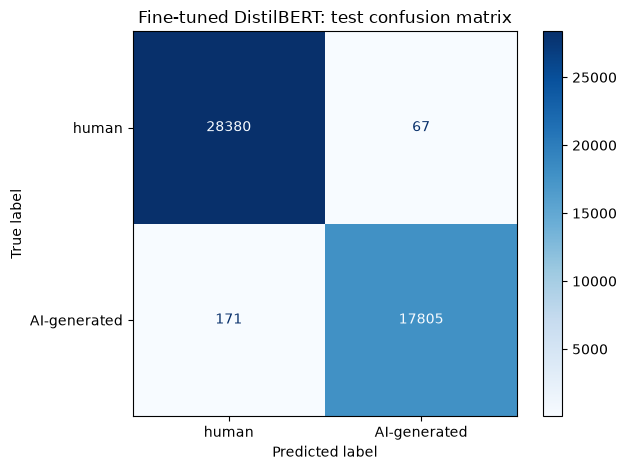

In [8]:
transformer_test_output = final_trainer.predict(
    tokenized["test"], metric_key_prefix="test"
)
transformer_predictions = np.argmax(transformer_test_output.predictions, axis=-1)
transformer_probabilities = torch.softmax(
    torch.tensor(transformer_test_output.predictions), dim=1
)[:, 1].numpy()

transformer_test_metrics = metrics_from_labels(
    test_df["label"].to_numpy(), transformer_predictions
)
transformer_test_metrics["loss"] = float(transformer_test_output.metrics["test_loss"])

print("=== Fine-tuned DistilBERT test results ===")
display(pd.DataFrame([transformer_test_metrics]).round(4))
print(
    classification_report(
        test_df["label"],
        transformer_predictions,
        target_names=["human", "AI-generated"],
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    test_df["label"],
    transformer_predictions,
    display_labels=["human", "AI-generated"],
    cmap="Blues",
    values_format="d",
)
plt.title("Fine-tuned DistilBERT: test confusion matrix")
plt.tight_layout()
plt.show()

transformer_prediction_table = pd.DataFrame(
    {
        "source_row_id": test_df["source_row_id"].to_numpy(),
        "true_label": test_df["label"].to_numpy(),
        "distilbert_prediction": transformer_predictions,
        "distilbert_ai_probability": transformer_probabilities,
    }
)
transformer_prediction_table.to_csv(
    RESULTS_DIR / "transformer_test_predictions.csv.gz",
    index=False,
    compression="gzip",
)
pd.DataFrame([transformer_test_metrics]).to_csv(
    RESULTS_DIR / "transformer_test_metrics.csv", index=False
)

## 7. Compare with the Week 1 classic baseline

For a fair comparison, the two Week 1 classic models, TF-IDF with Logistic Regression and TF-IDF with a Linear SVM, are fitted again on the same training rows and evaluated on the same test rows as DistilBERT. This avoids comparing scores from different data splits, and it keeps the strongest Week 1 baseline in the comparison instead of only Logistic Regression.

In [ ]:
def clean_for_baseline(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def build_tfidf_pipeline(classifier):
    return Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    ngram_range=(1, 2),
                    max_features=50_000,
                    min_df=5,
                    sublinear_tf=True,
                    stop_words="english",
                ),
            ),
            ("classifier", classifier),
        ]
    )

train_text = train_df["text"].map(clean_for_baseline)
test_text = test_df["text"].map(clean_for_baseline)

# The two Week 1 classic models are refit on the same training rows and scored
# on the same test rows as DistilBERT, so all three models are directly comparable.
classic_models = {
    "TF-IDF + Logistic Regression": LogisticRegression(max_iter=1_000, C=1.0),
    "TF-IDF + Linear SVM": LinearSVC(C=1.0),
}

classic_predictions = {}
comparison_rows = []
for name, classifier in classic_models.items():
    pipeline = build_tfidf_pipeline(classifier)
    pipeline.fit(train_text, train_df["label"])
    predictions = pipeline.predict(test_text)
    classic_predictions[name] = predictions
    comparison_rows.append(
        {"model": name, **metrics_from_labels(test_df["label"], predictions)}
    )

comparison_rows.append(
    {
        "model": "Fine-tuned DistilBERT",
        **{
            metric: transformer_test_metrics[metric]
            for metric in ["accuracy", "precision", "recall", "f1"]
        },
    }
)

comparison = pd.DataFrame(comparison_rows).set_index("model")

comparison.to_csv(RESULTS_DIR / "model_comparison.csv")
display(comparison.round(4))

# Compare DistilBERT against the strongest classic model, not only Logistic Regression.
best_classic = comparison.drop(index="Fine-tuned DistilBERT")["f1"].idxmax()
print(f"=== Difference: DistilBERT minus {best_classic} ===")
for metric in ["accuracy", "precision", "recall", "f1"]:
    difference = (
        comparison.loc["Fine-tuned DistilBERT", metric]
        - comparison.loc[best_classic, metric]
    )
    direction = "higher" if difference > 0 else "lower" if difference < 0 else "equal"
    print(f"{metric:9s}: {difference:+.4f} ({direction})")

best_model = comparison["f1"].idxmax()
print(f"\nBest test-set model by F1: {best_model}")

comparison.plot(kind="bar", figsize=(9, 4.5), ylim=(0, 1), rot=0)
plt.title("Week 2 model comparison on the same test split")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

for name, predictions in classic_predictions.items():
    print(f"\n=== {name} classification report ===")
    print(
        classification_report(
            test_df["label"],
            predictions,
            target_names=["human", "AI-generated"],
            digits=4,
        )
    )

## 8. Week 2 completion checklist

After the notebook has been run successfully, confirm that its outputs show all of the following:

- [x] The AI vs. Human Text CSV was loaded with Hugging Face Datasets.
- [x] Train, validation, and test splits were created with a fixed seed and stratification.
- [x] The DistilBERT tokenizer correctly produced `input_ids` and `attention_mask`.
- [x] `AutoModelForSequenceClassification`, `TrainingArguments`, and `Trainer` were used.
- [x] Learning rate, batch size, and epoch experiments were completed and logged.
- [x] The best configuration was selected using validation F1 rather than test performance.
- [x] The selected model was evaluated on the test set using accuracy, precision, recall, and F1.
- [x] The Transformer was compared with the TF-IDF Logistic Regression and Linear SVM baselines on the same test rows.
- [x] The final model, experiment log, metrics, comparison table, and predictions were saved.

### Interpretation to include in the report

Use the generated experiment table to explain how the three hyperparameters affected validation performance. Then use the final comparison table to state whether DistilBERT performed better than the strongest classic baseline and by how much. Both classic models are scored on the same test rows, so report the best classic F1 next to the DistilBERT F1 rather than only the Logistic Regression result. A near-perfect score should be discussed cautiously: it may reflect patterns specific to this dataset rather than a universally reliable AI-text detector.